In [9]:
import pyodbc

In [10]:
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=LOCALHOST\SQLEXPRESS;' 
    'DATABASE=Northwind;'
    'Trusted_Connection=yes;'  
)


<>:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\USER\AppData\Local\Temp\ipykernel_30620\3761646960.py:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  'SERVER=LOCALHOST\SQLEXPRESS;'


In [11]:
cursor = conn.cursor()
cursor.execute("SELECT @@VERSION") 
for row in cursor:
    print(row)


('Microsoft SQL Server 2025 (RTM) - 17.0.1000.7 (X64) \n\tOct 21 2025 12:05:57 \n\tCopyright (C) 2025 Microsoft Corporation\n\tExpress Edition (64-bit) on Windows 10 Home 10.0 <X64> (Build 26200: ) (Hypervisor)\n',)


In [12]:
import pandas as pd
# السؤال 1: عدد المنتجات في كل تصنيف
query1 = """
SELECT 
    c.CategoryName,
    COUNT(p.ProductID) AS num_products
FROM Categories c
JOIN Products p ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY num_products DESC;
"""
connection = conn
df1 = pd.read_sql(query1, connection)

# السؤال 2: متوسط سعر المنتجات في كل تصنيف
query2 = """
SELECT 
    c.CategoryName,
    AVG(p.UnitPrice) AS avg_price
FROM Categories c
JOIN Products p ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY avg_price DESC;
"""
df2 = pd.read_sql(query2, connection)

# السؤال 3: عدد الموردين في كل دولة
query3 = """
SELECT 
    Country,
    COUNT(SupplierID) AS num_suppliers
FROM Suppliers
GROUP BY Country
ORDER BY num_suppliers DESC;
"""
df3 = pd.read_sql(query3, connection)

# السؤال 4: عدد العملاء في كل دولة
query4 = """
SELECT 
    Country,
    COUNT(CustomerID) AS num_customers
FROM Customers
GROUP BY Country
ORDER BY num_customers DESC;
"""
df4 = pd.read_sql(query4, connection)

# السؤال 5: عدد الموظفين في كل مدينة
query5 = """
SELECT 
    City,
    Country,
    COUNT(EmployeeID) AS num_employees
FROM Employees
GROUP BY City, Country
ORDER BY num_employees DESC;
"""
df5 = pd.read_sql(query5, connection)

# السؤال 6: المنتجات منخفضة المخزون
query6 = """
SELECT 
    ProductName,
    UnitsInStock,
    UnitsOnOrder
FROM Products
WHERE UnitsInStock < 10
ORDER BY UnitsInStock ASC;
"""
df6 = pd.read_sql(query6, connection)

# السؤال 7: عدد المنتجات لكل مورد
query7 = """
SELECT 
    s.CompanyName,
    s.Country,
    COUNT(p.ProductID) AS num_products
FROM Suppliers s
JOIN Products p ON p.SupplierID = s.SupplierID
GROUP BY s.CompanyName, s.Country
ORDER BY num_products DESC;
"""
df7 = pd.read_sql(query7, connection)

query8 = """
SELECT c.CategoryName,
       SUM(p.UnitsInStock * p.UnitPrice) AS total_inventory_value
FROM Categories c
JOIN Products p ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY total_inventory_value DESC;
"""
df8 = pd.read_sql(query8, conn)


query10 = """
SELECT e.FirstName, e.LastName,
    COUNT(et.TerritoryID) AS num_territories
FROM Employees e
JOIN EmployeeTerritories et ON et.EmployeeID = e.EmployeeID
GROUP BY e.FirstName, e.LastName
ORDER BY num_territories DESC;
"""
df10 = pd.read_sql(query10, conn)


query11 = """
SELECT TOP 10 City, Country,
    COUNT(CustomerID) AS num_customers
FROM Customers
GROUP BY City, Country
ORDER BY num_customers DESC;
"""
df11 = pd.read_sql(query11, conn)

query14 = """
SELECT ContactTitle,
    COUNT(CustomerID) AS num_customers
FROM Customers
WHERE ContactTitle IS NOT NULL
GROUP BY ContactTitle
ORDER BY num_customers DESC;
"""
df14 = pd.read_sql(query14, conn)


query15 = """
SELECT s.CompanyName,
    AVG(p.UnitPrice) AS avg_price,
    MAX(p.UnitPrice) AS max_price
FROM Suppliers s
JOIN Products p ON p.SupplierID = s.SupplierID
GROUP BY s.CompanyName
ORDER BY avg_price DESC;
"""
df15 = pd.read_sql(query15, conn)


query16 = """
SELECT 
    r.RegionDescription,
    COUNT(t.TerritoryID) AS num_territories
FROM Region r
JOIN Territories t ON t.RegionID = r.RegionID
GROUP BY r.RegionDescription
ORDER BY num_territories DESC;
"""
df16 = pd.read_sql(query16, conn)


query17 = """
SELECT 
    p.ProductName,
    c.CategoryName,
    p.UnitPrice
FROM Products p
JOIN Categories c ON c.CategoryID = p.CategoryID
WHERE p.UnitPrice > (
    SELECT AVG(p2.UnitPrice) 
    FROM Products p2 
    WHERE p2.CategoryID = p.CategoryID
)
ORDER BY p.UnitPrice DESC;
"""
df17 = pd.read_sql(query17, conn)


query18 = """
SELECT 
    s.CompanyName,
    COUNT(p.ProductID) AS num_products
FROM Suppliers s
JOIN Products p ON p.SupplierID = s.SupplierID
GROUP BY s.CompanyName
HAVING COUNT(p.ProductID) > 2
ORDER BY num_products DESC;
"""
df18 = pd.read_sql(query18, conn)



query19 = """
SELECT 
    Region,
    COUNT(CustomerID) AS num_customers
FROM Customers
WHERE Region IS NOT NULL
GROUP BY Region
ORDER BY num_customers DESC;
"""
df19 = pd.read_sql(query19, connection)



connection.close()
print("تم تنفيذ كل الاستعلامات ✅")

تم تنفيذ كل الاستعلامات ✅


C:\Users\USER\AppData\Local\Temp\ipykernel_30620\1072510214.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(query1, connection)
C:\Users\USER\AppData\Local\Temp\ipykernel_30620\1072510214.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query2, connection)
C:\Users\USER\AppData\Local\Temp\ipykernel_30620\1072510214.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql(query3, connection)
C:\Users\USER\AppData\Local\Temp\ipykernel_30620\1072510214.py:47: UserWarni

In [13]:
# Duplicate connection.close() removed. No action needed — connection was closed in CELL INDEX: 3.

In [14]:
print(df1.head(10))

     CategoryName  num_products
0     Confections            13
1       Beverages            12
2      Condiments            12
3         Seafood            12
4  Dairy Products            10
5  Grains/Cereals             7
6    Meat/Poultry             6
7         Produce             5


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

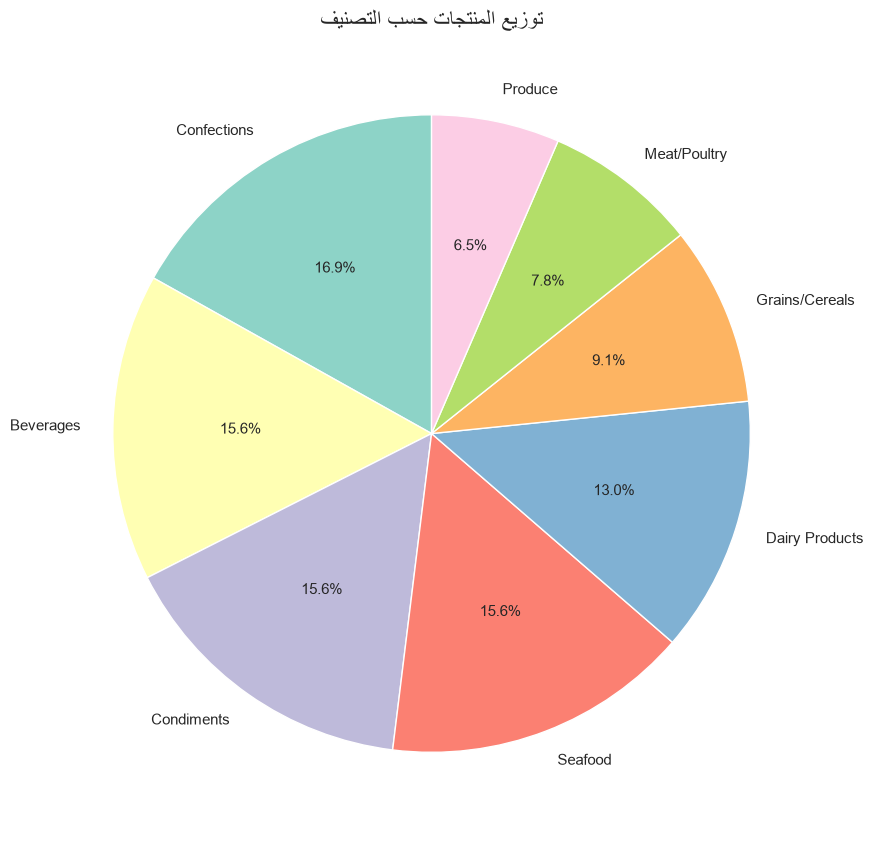

In [16]:
plt.figure(figsize=(9,9))
colors = sns.color_palette('Set3', len(df1))
plt.pie(df1['num_products'], labels=df1['CategoryName'], autopct='%1.1f%%', 
        colors=colors, startangle=90, textprops={'fontsize': 11})
plt.title('توزيع المنتجات حسب التصنيف', fontsize=16)
plt.tight_layout()
plt.savefig('chart1_pie_products_category.png', dpi=300)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_30620\3442166122.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df2, x='CategoryName', y='avg_price', palette='magma')


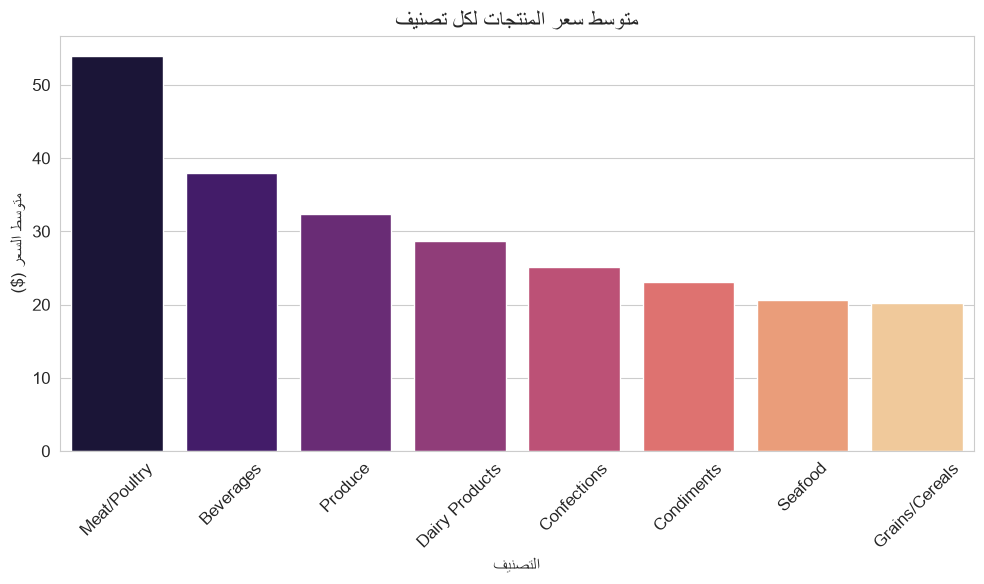

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(data=df2, x='CategoryName', y='avg_price', palette='magma')
plt.title('متوسط سعر المنتجات لكل تصنيف', fontsize=16)
plt.xlabel('التصنيف')
plt.ylabel('متوسط السعر ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_avg_price_per_category.png', dpi=300)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_30620\1418711258.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df3, y='Country', x='num_suppliers', palette='crest')


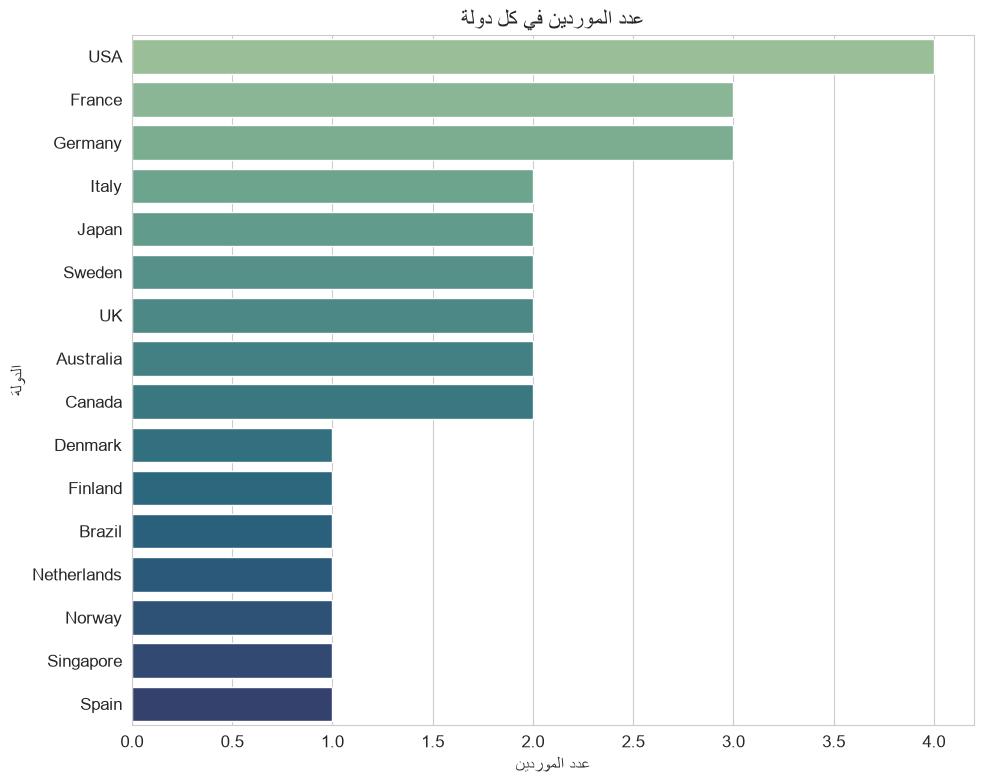

In [18]:
plt.figure(figsize=(10,8))
sns.barplot(data=df3, y='Country', x='num_suppliers', palette='crest')
plt.title('عدد الموردين في كل دولة', fontsize=16)
plt.xlabel('عدد الموردين')
plt.ylabel('الدولة')
plt.tight_layout()
plt.savefig('chart3_suppliers_per_country.png', dpi=300)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_30620\101336723.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df4, y='Country', x='num_customers', palette='flare')


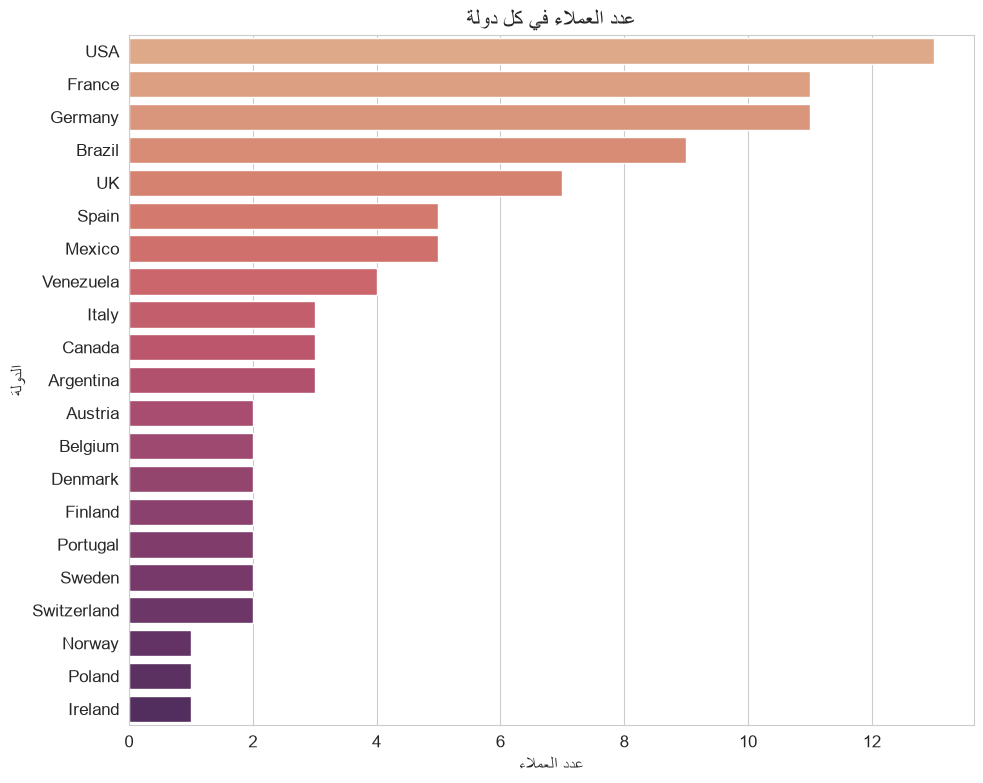

In [19]:
plt.figure(figsize=(10,8))
sns.barplot(data=df4, y='Country', x='num_customers', palette='flare')
plt.title('عدد العملاء في كل دولة', fontsize=16)
plt.xlabel('عدد العملاء')
plt.ylabel('الدولة')
plt.tight_layout()
plt.savefig('chart4_customers_per_country.png', dpi=300)
plt.show()

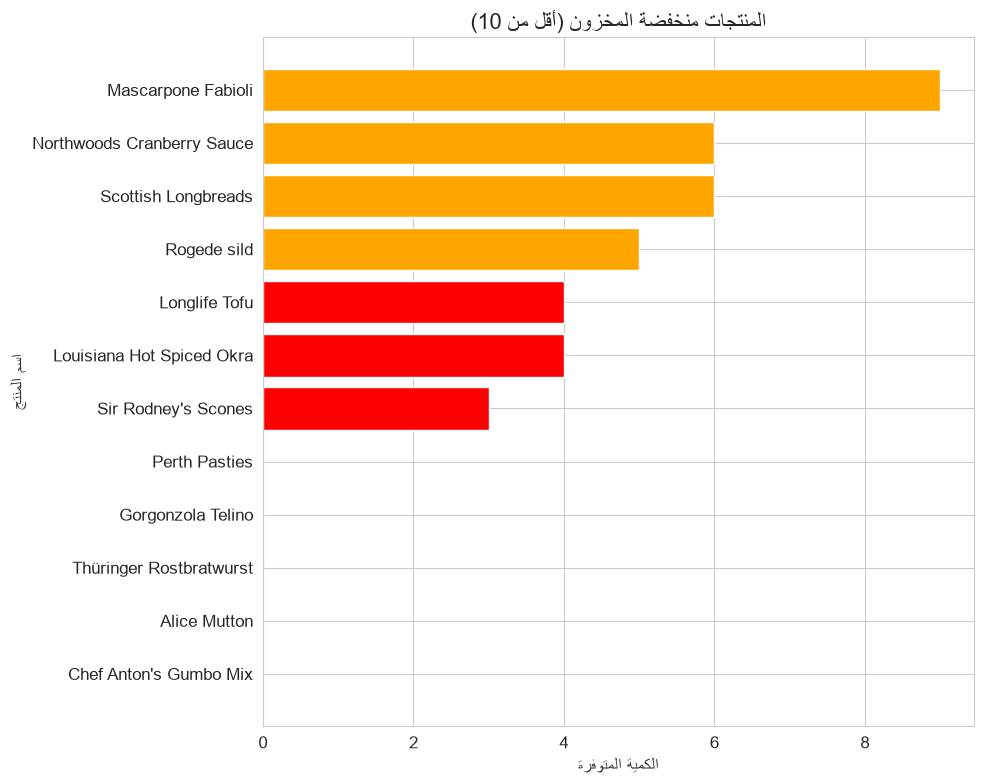

In [20]:
plt.figure(figsize=(10,8))
colors = ['red' if x < 5 else 'orange' for x in df6['UnitsInStock']]
plt.barh(df6['ProductName'], df6['UnitsInStock'], color=colors)
plt.title('المنتجات منخفضة المخزون (أقل من 10)', fontsize=16)
plt.xlabel('الكمية المتوفرة')
plt.ylabel('اسم المنتج')
plt.tight_layout()
plt.savefig('chart6_low_stock_products.png', dpi=300)
plt.show()

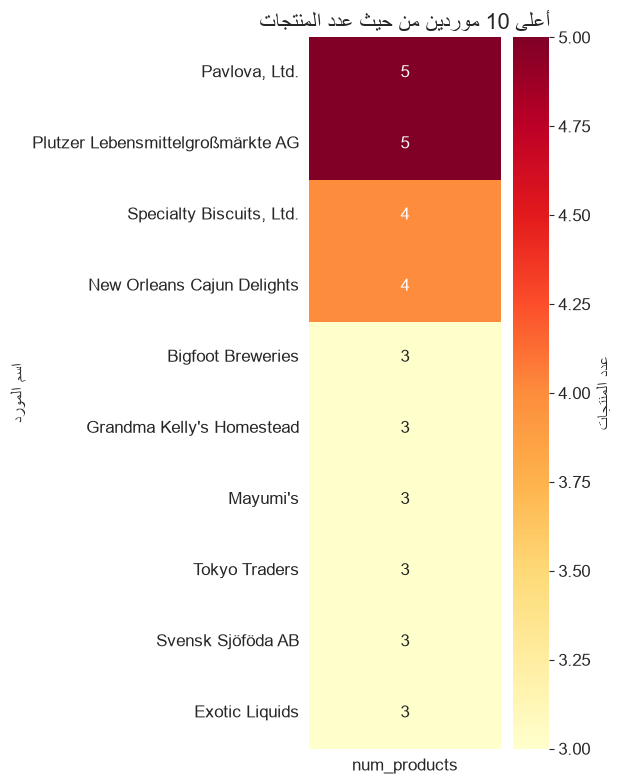

In [21]:
# ناخد أعلى 10 موردين بس عشان الرسم يبقى واضح
df7_top10 = df7.head(10).set_index('CompanyName')[['num_products']]

plt.figure(figsize=(6,8))
sns.heatmap(df7_top10, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'عدد المنتجات'})
plt.title('أعلى 10 موردين من حيث عدد المنتجات', fontsize=16)
plt.ylabel('اسم المورد')
plt.xlabel('')
plt.tight_layout()
plt.savefig('chart7_heatmap_suppliers.png', dpi=300)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_30620\2118319366.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df8, x='CategoryName', y='total_inventory_value', palette='crest')


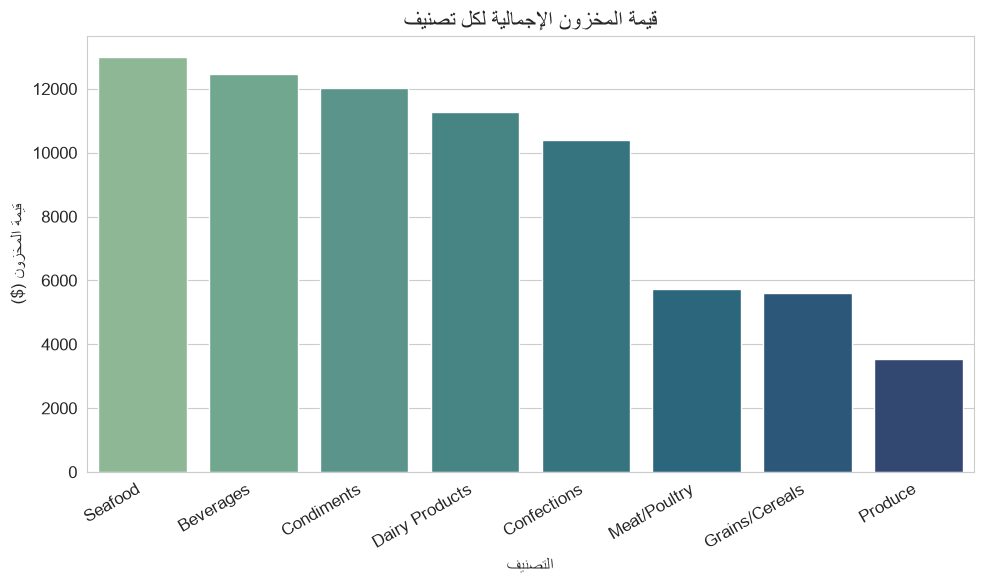

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(data=df8, x='CategoryName', y='total_inventory_value', palette='crest')
plt.title('قيمة المخزون الإجمالية لكل تصنيف', fontsize=16)
plt.xlabel('التصنيف')
plt.ylabel('قيمة المخزون ($)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart8_inventory_value.png', dpi=300)
plt.show()

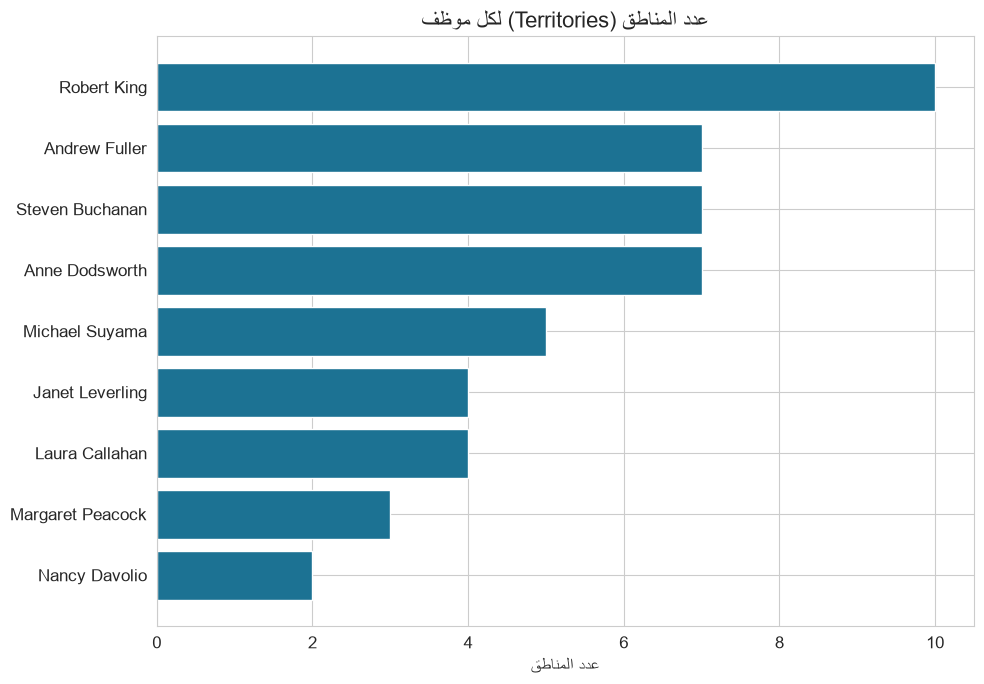

In [23]:
plt.figure(figsize=(10,7))
df10_sorted = df10.sort_values('num_territories')
plt.barh(df10_sorted['FirstName'] + ' ' + df10_sorted['LastName'], df10_sorted['num_territories'], color='#1C7293')
plt.title('عدد المناطق (Territories) لكل موظف', fontsize=16)
plt.xlabel('عدد المناطق')
plt.tight_layout()
plt.savefig('chart10_territories.png', dpi=300)
plt.show()

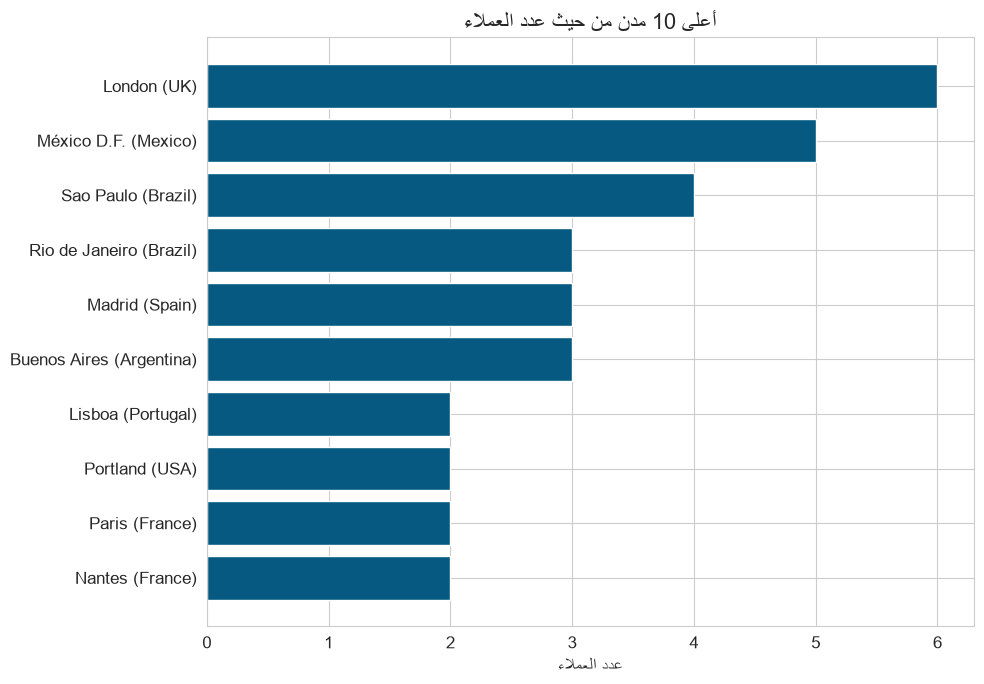

In [24]:
plt.figure(figsize=(10,7))
df11['label'] = df11['City'] + ' (' + df11['Country'] + ')'
df11_sorted = df11.sort_values('num_customers')
plt.barh(df11_sorted['label'], df11_sorted['num_customers'], color='#065A82')
plt.title('أعلى 10 مدن من حيث عدد العملاء', fontsize=16)
plt.xlabel('عدد العملاء')
plt.tight_layout()
plt.savefig('chart11_top_cities.png', dpi=300)
plt.show()

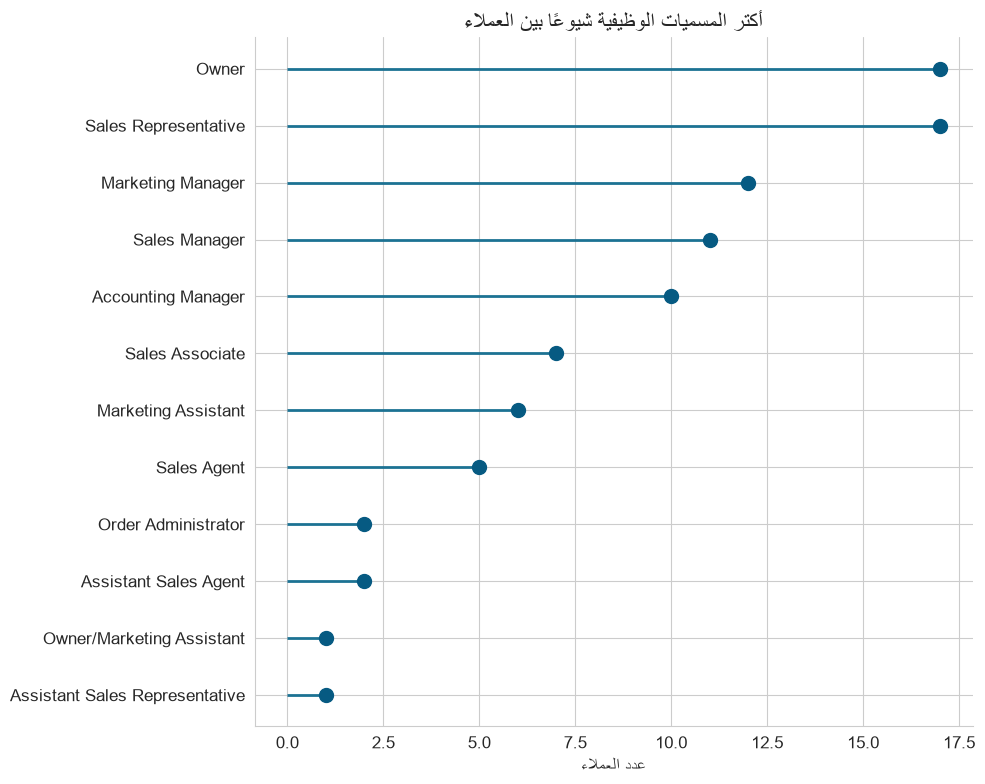

In [25]:
plt.figure(figsize=(10,8))
df14_sorted = df14.sort_values('num_customers')

plt.hlines(y=df14_sorted['ContactTitle'], xmin=0, xmax=df14_sorted['num_customers'], color='#1C7293', linewidth=2)
plt.plot(df14_sorted['num_customers'], df14_sorted['ContactTitle'], "o", markersize=10, color='#065A82')

plt.title('أكتر المسميات الوظيفية شيوعًا بين العملاء', fontsize=16)
plt.xlabel('عدد العملاء')
sns.despine()
plt.tight_layout()
plt.savefig('chart14_contact_titles_lollipop.png', dpi=300)
plt.show()

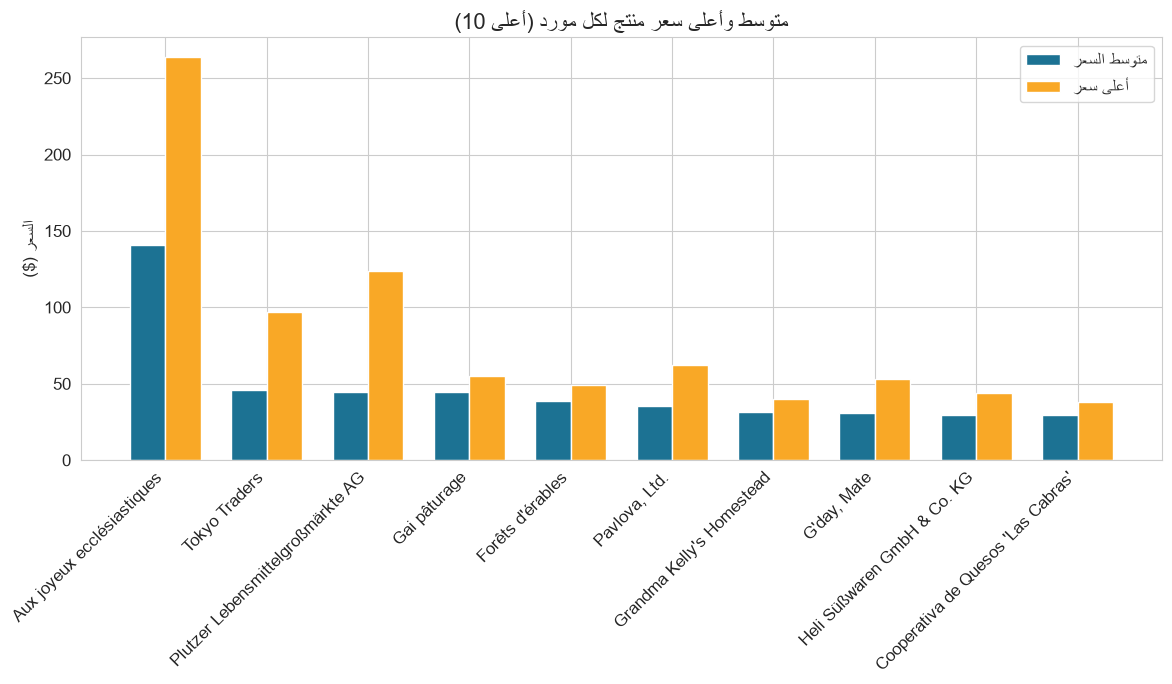

In [26]:
df15_top10 = df15.head(10)
x = range(len(df15_top10))
width = 0.35

plt.figure(figsize=(12,7))
plt.bar([i - width/2 for i in x], df15_top10['avg_price'], width, label='متوسط السعر', color='#1C7293')
plt.bar([i + width/2 for i in x], df15_top10['max_price'], width, label='أعلى سعر', color='#F9A826')
plt.xticks(x, df15_top10['CompanyName'], rotation=45, ha='right')
plt.title('متوسط وأعلى سعر منتج لكل مورد (أعلى 10)', fontsize=16)
plt.ylabel('السعر ($)')
plt.legend()
plt.tight_layout()
plt.savefig('chart15_supplier_pricing.png', dpi=300)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_30620\1205999552.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_dist.index, y=price_dist.values, palette='mako')


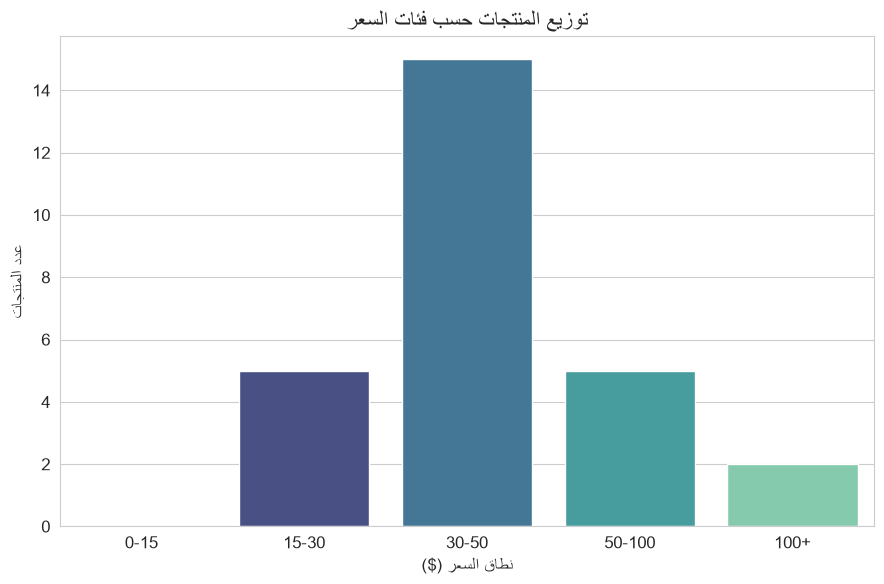

In [34]:
df16 = df17.copy()
bins = [0, 15, 30, 50, 100, df16['UnitPrice'].max() + 1]
labels = ['0-15', '15-30', '30-50', '50-100', '100+']
df16['price_range'] = pd.cut(df16['UnitPrice'], bins=bins, labels=labels)

price_dist = df16['price_range'].value_counts().sort_index()

plt.figure(figsize=(9,6))
sns.barplot(x=price_dist.index, y=price_dist.values, palette='mako')
plt.title('توزيع المنتجات حسب فئات السعر', fontsize=16)
plt.xlabel('نطاق السعر ($)')
plt.ylabel('عدد المنتجات')
plt.tight_layout()
plt.savefig('chart16_price_distribution.png', dpi=300)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_30620\2241902978.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df17_summary, x='CategoryName', y='premium_products_count', palette='flare')


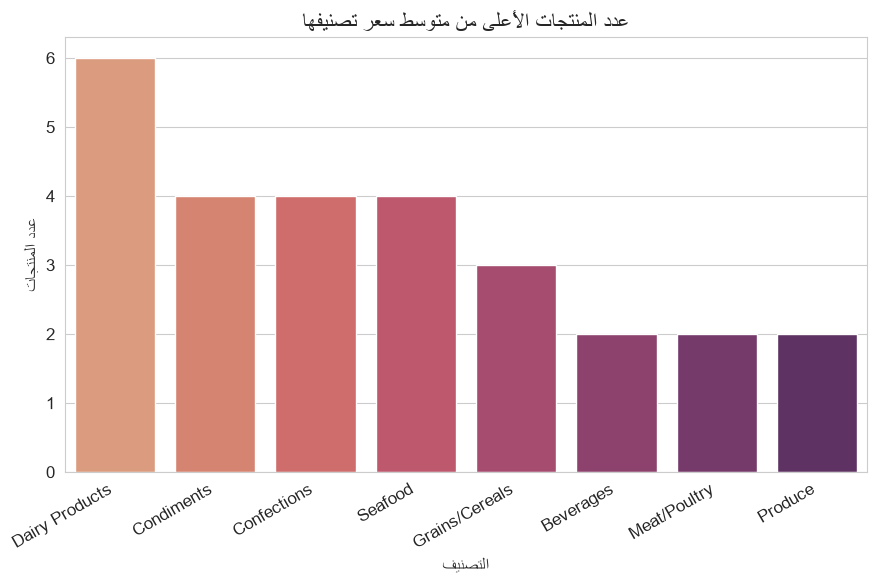

In [28]:
df17_summary = df17.groupby('CategoryName').size().reset_index(name='premium_products_count')
df17_summary = df17_summary.sort_values('premium_products_count', ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(data=df17_summary, x='CategoryName', y='premium_products_count', palette='flare')
plt.title('عدد المنتجات الأعلى من متوسط سعر تصنيفها', fontsize=16)
plt.xlabel('التصنيف')
plt.ylabel('عدد المنتجات')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart17_premium_products.png', dpi=300)
plt.show()

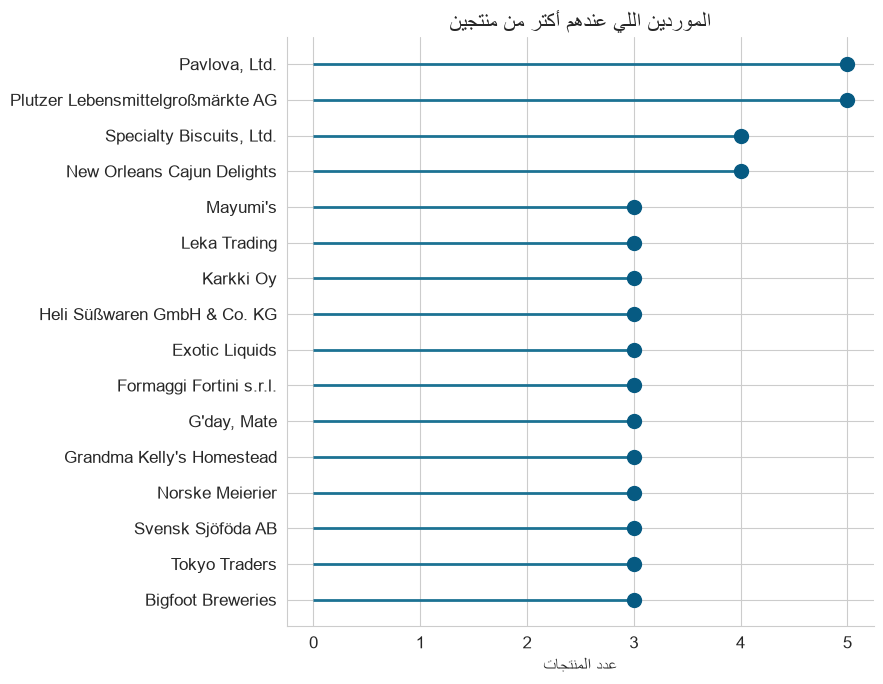

In [29]:
plt.figure(figsize=(9,7))
df18_sorted = df18.sort_values('num_products')
plt.hlines(y=df18_sorted['CompanyName'], xmin=0, xmax=df18_sorted['num_products'], color='#1C7293', linewidth=2)
plt.plot(df18_sorted['num_products'], df18_sorted['CompanyName'], "o", markersize=10, color='#065A82')
plt.title('الموردين اللي عندهم أكتر من منتجين', fontsize=16)
plt.xlabel('عدد المنتجات')
sns.despine()
plt.tight_layout()
plt.savefig('chart18_suppliers_having.png', dpi=300)
plt.show()

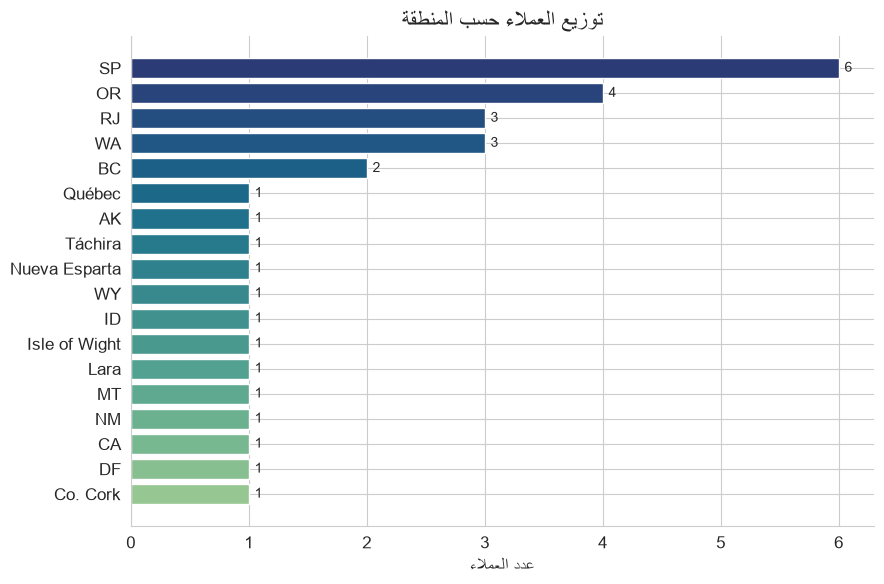

In [40]:
plt.figure(figsize=(9,6))
df19_sorted = df19.sort_values('num_customers')
colors = sns.color_palette('crest', len(df19_sorted))
plt.barh(df19_sorted['Region'], df19_sorted['num_customers'], color=colors)

for i, v in enumerate(df19_sorted['num_customers']):
    plt.text(v + 0.05, i, str(v), va='center', fontsize=10)

plt.title('توزيع العملاء حسب المنطقة', fontsize=16)
plt.xlabel('عدد العملاء')
sns.despine()
plt.tight_layout()
plt.savefig('chart19_customers_by_region.png', dpi=300)
plt.show()
